## STEP 1: Import libraries.   

In [44]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Step 2: Load the dataset

In [45]:
# Load the dataset
financial_data = pd.read_excel(r"C:\Users\hp\Desktop\Data Science & Analytics (LuxDevHQ)\AUGUST\week19_ml_project\data\raw\finaccess2024_datasprint.xlsx")


In [46]:
financial_data

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,Loan_formal,Loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,No,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,Yes,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,Usage,Non-usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20866,Wajir,Rural,Female,36-45,8,"""None """,Married/Living with partner,6600,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,One correct,2,Awareness,Without Disability
20867,Nairobi City,Urban,Female,18-25,4,"""Some secondary""",Married/Living with partner,10000,Usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,No,No,Worsened,Two correct,3,Affordability,Without Disability
20868,Embu,Rural,Male,Above 55,6,"""Some primary """,Widowed,6000,Non-usage,Non-usage,Non-usage,Usage,Yes,Usage,Yes,0,Yes,No,No,Yes,Yes,No,No,Stayed the same,None correct,4,NaN,Without Disability
20869,Taita-Taveta,Urban,Female,26-35,7,"""Primary completed""",Single/Never Married,13000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,Yes,No,No,No,Stayed the same,All correct,6,Affordability,Without Disability


## STEP 3: Checking the overview of the dataset

In [47]:
def basic_checks(data):
    print("-"*35, "Duplicates","-"*35)
    print(data.duplicated().sum())
    print("-"*35, "Shape", "-"*35)
    print(data.shape)
    print("-"*35, "Missing Values", "-"*35)
    print(data.isna().sum())
    print("-"*35, "Data Types", "-"*35)
    print(data.dtypes)
    print("-"*35, "Summary Statistics (Numerical)", "-"*35)
    print(display(data.describe().T))
    print("-"*35, "Summary Statistics Categorical Data", "-"*35)
    print(display(data.describe(include = ["str","object"]).T))



In [48]:
basic_checks(financial_data)

----------------------------------- Duplicates -----------------------------------
5
----------------------------------- Shape -----------------------------------
(20871, 28)
----------------------------------- Missing Values -----------------------------------
county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score          

,count,mean,std,min,25%,50%,75%,max
household_size,20871.0,4.215946,2.512658,1.0,2.0,4.0,6.0,20.0
monthly_income,20871.0,9702.774280,15423.366592,100.0,2500.0,5000.0,10000.0,200000.0
prodsum1,20871.0,3.936563,3.227992,0.0,1.0,3.0,6.0,22.0


None
----------------------------------- Summary Statistics Categorical Data -----------------------------------


,count,unique,top,freq
county,20871,47,Meru,637
location_type,20871,2,Rural,13549
Sex,20871,2,Female,12326
Age,20871,6,26-35,5361
education_level,20871,13,"""Secondary completed """,4113
marital_status,20871,6,Married/Living with partner,11432
Savings_formal,20871,2,Non-usage,11635
Savings_informal,20871,2,Non-usage,16031
Loan_formal,20871,2,Non-usage,12340
Loan_informal,20871,2,Non-usage,12604


None


__Categorical Entries__

In [49]:
categorical_columns = financial_data.select_dtypes(include = ["str", "object"]).columns.to_list()

In [50]:
print(categorical_columns)

for col in categorical_columns:
    print("-"*35, col.upper(), "-"*35)
    print(financial_data[col].unique())
    print("Count: ", financial_data[col].nunique())

['county', 'location_type', 'Sex', 'Age', 'education_level', 'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status', 'fl_score', 'barriers_bank', 'has_disability']
----------------------------------- COUNTY -----------------------------------
<StringArray>
[        'Garissa',           'Busia',          'Kiambu',        'Murang'a',
          'Kilifi',            'Meru',          'Kisumu',         'Baringo',
          'Isiolo',            'Embu',         'Mombasa', 'Elgeyo-Marakwet',
         'Homabay',          'Migori',           'Siaya',      'West Pokot',
           'Nyeri',           'Bomet',         'Makueni',     'Uasin Gishu',
         'Bungoma',          'Nakuru',        'Kakamega',           'Kwale',
           'Kitui',         'M

__Check for Outliers__

['household_size', 'monthly_income', 'prodsum1']


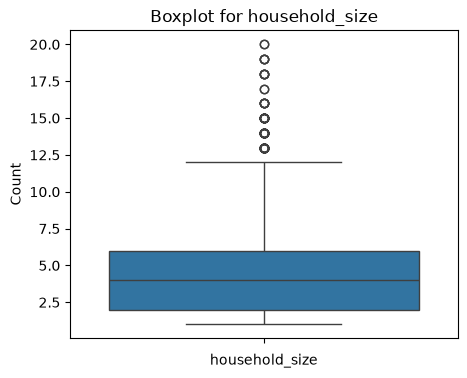

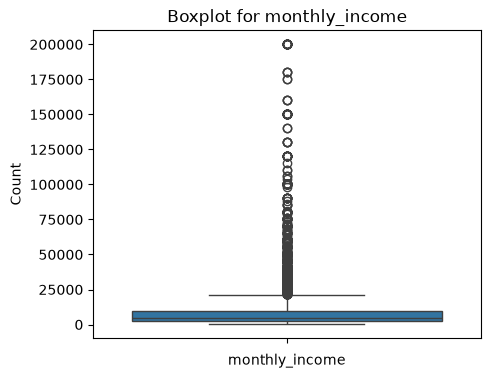

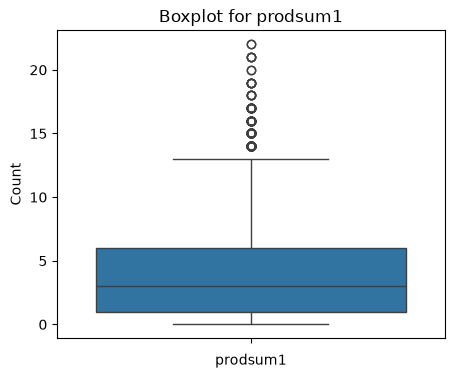

In [51]:
num_cols = financial_data.select_dtypes(include=["int", "float"]).columns.to_list()
print(num_cols)

for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(data = financial_data, y= col)
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# STEP 3: Data Cleaning

__Drop Duplicates__

In [52]:
# Drop duplicates
financial_data.drop_duplicates(inplace = True)

# Check if the have been dropped
financial_data.duplicated().sum()


np.int64(0)

__Cleaning Categorical Entries__

__Remove "Completed technical training after secondary school", "Some Technical Training and replace with "Technical Training__

In [57]:
# Strip all trailing and preceding spaces from all the categorical columns
for col in categorical_columns:
    financial_data[col] = financial_data[col].astype(str).str.strip()


In [58]:
# Remove 'Completed technical training after secondary school', 'Some technical training after secondary school' replace with 'Technical Training'
mapping = {'Completed technical training after secondary school':'Technical training',
           'Some technical training after secondary school':'Technical training',
           '"Secondary completed "':'Secondary',
           '"Primary completed"':'Primary',
           '"Some primary "':'Primary incomplete',
           '"None "':'None',
           '"Some secondary"':'Secondary incomplete',
           '"University completed "':'University',
           'Some university':'University incomplete',
           '"Refused to Answer (DO NOT READ OUT)"':'',
           '"Other (Specify) "':'',
           '95':''
           }


financial_data = financial_data.replace(mapping)

In [59]:
(financial_data['education_level'].value_counts()/len(financial_data))*100

education_level
Secondary                         19.711492
Primary                           18.944695
Primary incomplete                17.880763
None                              14.727308
Secondary incomplete              13.088278
Technical training                 9.211157
University                         4.734976
University incomplete              1.658200
                                   0.033547
"Don't know (DO NOT READ OUT)"     0.009585
Name: count, dtype: float64

In [ ]:
financial_data["education_level"] = financial_data["education_level"].astype("category")
financial_data["education_level"] = financial_data["education_level"].cat.remove_categories(["Refused to Answer (DO NOT READ OUT)",
                                                                                         "Other (Specify) ",
                                                                                         95,"Don't know (DO NOT READ OUT)"])

AttributeError: 'Series' object has no attribute 'remove_categories'